In [ ]:
import pandas as pd
from google.colab import files
import io

# Upload a file. A file selection dialog will appear. Choose your CSV file.
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the uploaded file into a DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Saving cancer_data.csv to cancer_data.csv
User uploaded file "cancer_data.csv" with length 34286266 bytes


,0,1,2,3,4,5,6,7,8,9,...,962,963,964,965,966,967,968,969,970,971
0,44.023542,9.216286,11.319078,33.215176,16.901427,9.031338,1.109961,20.017821,16.724363,10.494192,...,21.706486,16.315579,4.224009,8.602081,23.762341,8.302416,1.408731,4.295620,8.768768,1.0
1,29.746157,9.765600,40.540128,30.169134,20.047393,32.237287,2.460624,17.029112,28.346167,17.017284,...,12.815215,10.150965,8.914809,6.797915,15.379187,11.420690,6.599729,3.819019,5.758501,1.0
2,35.799315,9.884781,3.886043,29.984211,17.135946,21.273727,1.501203,20.598204,25.855152,12.275738,...,14.344729,11.224647,7.870991,7.724003,25.762396,8.628786,4.104879,4.382387,5.306177,1.0
3,26.490401,7.085828,10.804003,23.482255,17.044085,14.880104,1.299056,14.978582,31.214294,10.015235,...,13.660995,9.730124,7.804760,5.030966,8.964868,7.990036,4.251886,3.702483,7.500498,1.0
4,27.632466,7.642971,3.670265,16.584843,20.375321,22.174600,1.553541,14.909150,54.435490,13.392213,...,16.650019,8.584938,7.485410,5.945771,9.205302,8.761025,4.656969,3.827945,7.939863,1.0


### Data Preprocessing

First, let's rename the last column to 'target' as you requested.

In [ ]:
target_column_name = df.columns[-1]
df = df.rename(columns={target_column_name: 'target'})

print(f"Renamed column '{target_column_name}' to 'target'.")
display(df.head())

Renamed column '971' to 'target'.


,0,1,2,3,4,5,6,7,8,9,...,962,963,964,965,966,967,968,969,970,target
0,44.023542,9.216286,11.319078,33.215176,16.901427,9.031338,1.109961,20.017821,16.724363,10.494192,...,21.706486,16.315579,4.224009,8.602081,23.762341,8.302416,1.408731,4.295620,8.768768,1.0
1,29.746157,9.765600,40.540128,30.169134,20.047393,32.237287,2.460624,17.029112,28.346167,17.017284,...,12.815215,10.150965,8.914809,6.797915,15.379187,11.420690,6.599729,3.819019,5.758501,1.0
2,35.799315,9.884781,3.886043,29.984211,17.135946,21.273727,1.501203,20.598204,25.855152,12.275738,...,14.344729,11.224647,7.870991,7.724003,25.762396,8.628786,4.104879,4.382387,5.306177,1.0
3,26.490401,7.085828,10.804003,23.482255,17.044085,14.880104,1.299056,14.978582,31.214294,10.015235,...,13.660995,9.730124,7.804760,5.030966,8.964868,7.990036,4.251886,3.702483,7.500498,1.0
4,27.632466,7.642971,3.670265,16.584843,20.375321,22.174600,1.553541,14.909150,54.435490,13.392213,...,16.650019,8.584938,7.485410,5.945771,9.205302,8.761025,4.656969,3.827945,7.939863,1.0


In [ ]:
pply

Now, we will separate the features (all columns except 'target') and apply Min-Max normalization to them.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max normalization to the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features normalized using Min-Max scaling.")
print("Original features shape:", X.shape)
print("Scaled features shape:", X_scaled_df.shape)
display(X_scaled_df.head())

Features normalized using Min-Max scaling.
Original features shape: (2086, 971)
Scaled features shape: (2086, 971)


,0,1,2,3,4,5,6,7,8,9,...,961,962,963,964,965,966,967,968,969,970
0,0.237892,0.082832,0.020102,0.302737,0.050826,0.046596,0.013514,0.497457,0.038969,0.084320,...,0.069896,0.168754,0.341778,0.049079,0.186027,0.093705,0.112600,0.033977,0.092447,0.217877
1,0.145298,0.088527,0.077114,0.272476,0.061027,0.225673,0.034881,0.416975,0.069264,0.144424,...,0.165745,0.096844,0.195057,0.116374,0.143712,0.059204,0.162041,0.219174,0.081110,0.136299
2,0.184555,0.089762,0.005600,0.270638,0.051586,0.141069,0.019703,0.513086,0.062771,0.100735,...,0.109929,0.109214,0.220611,0.101399,0.165433,0.101937,0.117775,0.130167,0.094511,0.124041
3,0.124184,0.060745,0.019098,0.206044,0.051288,0.091730,0.016505,0.361757,0.076741,0.079907,...,0.127341,0.103684,0.185041,0.100449,0.102269,0.032805,0.107647,0.135411,0.078338,0.183507
4,0.131590,0.066521,0.005179,0.137520,0.062090,0.148021,0.020531,0.359887,0.137273,0.111023,...,0.139652,0.127859,0.157785,0.095868,0.123725,0.033795,0.119871,0.149863,0.081322,0.195414


### Splitting Data into Training and Testing Sets

Now, let's split our normalized feature data (`X_scaled_df`) and target data (`y`) into training and testing sets. This is a crucial step for model evaluation, ensuring that the model is tested on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Using a common split ratio (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (1668, 971)
X_test shape: (418, 971)
y_train shape: (1668,)
y_test shape: (418,)


### Applying SMOTE for Data Augmentation

To address potential class imbalance in the training data, we will use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class(es). This is applied to `X_train` and `y_train`.

In [ ]:
from imblearn.over_sampling import SMOTE

# Before applying SMOTE, let's check the class distribution of y_train
print("Class distribution before SMOTE:")
print(y_train.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

print(f"\nShape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Shape of y_train before SMOTE: {y_train.shape}")
print(f"Shape of y_train after SMOTE: {y_train_smote.shape}")

Class distribution before SMOTE:
target
1.0    694
2.0    440
5.0    224
4.0    190
3.0    120
Name: count, dtype: int64

Class distribution after SMOTE:
target
1.0    694
2.0    694
4.0    694
3.0    694
5.0    694
Name: count, dtype: int64

Shape of X_train before SMOTE: (1668, 971)
Shape of X_train after SMOTE: (3470, 971)
Shape of y_train before SMOTE: (1668,)
Shape of y_train after SMOTE: (3470,)


### Feature Selection using Recursive Feature Elimination (RFE)

As requested, we will now apply a wrapper method for feature selection: Recursive Feature Elimination (RFE) with a Logistic Regression estimator. This technique will help reduce the number of features from the current 971 to 50, focusing on the most relevant features for the target variable.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression estimator.
# Setting max_iter for convergence with a large number of features.
estimator = LogisticRegression(solver='liblinear', max_iter=200, random_state=42)

# Initialize RFE with the estimator and the desired number of features
rfe_selector = RFE(estimator=estimator, n_features_to_select=50, step=1, verbose=0)

# Fit RFE to the SMOTE-augmented training data
rfe_selector.fit(X_train_smote, y_train_smote)

# Transform the training and test sets to include only the selected features
X_train_selected = rfe_selector.transform(X_train_smote)
X_test_selected = rfe_selector.transform(X_test)

# Get the names of the selected features
selected_features_indices = rfe_selector.support_
selected_feature_names = X_train_smote.columns[selected_features_indices]

print("Feature selection completed using RFE.")
print(f"Number of features before RFE: {X_train_smote.shape[1]}")
print(f"Number of features after RFE: {X_train_selected.shape[1]}")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

print("\nTop 50 selected features (column indices):")
print(selected_feature_names.tolist())

Feature selection completed using RFE.
Number of features before RFE: 971
Number of features after RFE: 50
Shape of X_train_selected: (3470, 50)
Shape of X_test_selected: (418, 50)

Top 50 selected features (column indices):
['10', '31', '39', '41', '48', '52', '54', '95', '122', '169', '216', '252', '273', '282', '321', '324', '334', '341', '342', '373', '384', '501', '508', '523', '555', '595', '610', '624', '631', '636', '656', '665', '704', '712', '719', '722', '735', '743', '768', '787', '788', '805', '809', '820', '846', '861', '875', '885', '897', '966']


### Transformer Model Implementation

Now, let's implement the Transformer model components based on the specified parameters. We'll start by defining the `TransformerBlock` and `TokenAndPositionEmbedding` layers, then assemble them into the full Transformer model.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Ensure y_train_smote is in a suitable format (e.g., one-hot encoded if multi-class)
# Assuming y_train_smote contains integer labels
num_classes = len(np.unique(y_train_smote))

# Convert X_train_selected to a suitable format for the embedding layer (e.g., float32)
X_train_selected = X_train_selected.astype(np.float32)
X_test_selected = X_test_selected.astype(np.float32)


#### Transformer Block

This block implements the core components of a transformer layer: multi-head self-attention, layer normalization, and a feed-forward network. Residual connections and dropout are applied as well.

In [ ]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False): # Changed to training=False
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super(TransformerBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config


#### Token and Position Embedding

This layer combines a token embedding (to convert input features into a dense vector representation) with a positional embedding (to encode the order of features). Since the input is already numerical features, we'll treat them as 'tokens' and apply a dense layer to project them to `embed_dim`.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_45 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_19 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_31            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_32            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

In [ ]:
batch_size = 32
epochs = 50 # Using the higher end of the suggested range (40-50)

y_train_smote_int = y_train_smote.astype(int)
y_test_int = y_test.astype(int)

history = model.fit(
    X_train_selected,
    y_train_smote_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_selected, y_test_int)
)


Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

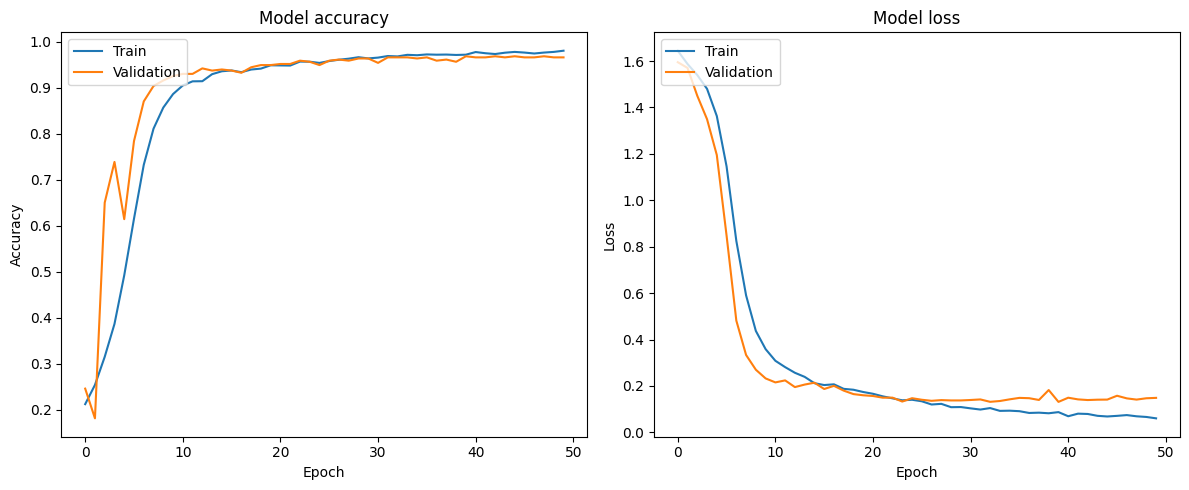

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_42 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_18 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_29            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_30            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_112 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_113 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

In [ ]:
batch_size = 32
epochs = 50 # Using the higher end of the suggested range (40-50)

y_train_smote_int = y_train_smote.astype(int)
y_test_int = y_test.astype(int)

history = model.fit(
    X_train_selected,
    y_train_smote_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_selected, y_test_int)
)


Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_39 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_17 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_27            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_28            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_16 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_25            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_26            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_15 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_23            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_24            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_14 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_21            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_22            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

In [ ]:
batch_size = 32
epochs = 50 # Using the higher end of the suggested range (40-50)

y_train_smote_int = y_train_smote.astype(int)
y_test_int = y_test.astype(int)

history = model.fit(
    X_train_selected,
    y_train_smote_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_selected, y_test_int)
)


Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_13 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_19            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_20            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

In [ ]:
batch_size = 32
epochs = 50 # Using the higher end of the suggested range (40-50)

y_train_smote_int = y_train_smote.astype(int) - 1  # Subtract 1 to make labels 0-indexed
y_test_int = y_test.astype(int) - 1          # Subtract 1 to make labels 0-indexed

history = model.fit(
    X_train_selected,
    y_train_smote_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_selected, y_test_int)
)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.2127 - loss: 1.6446 - val_accuracy: 0.2464 - val_loss: 1.5951
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.2545 - loss: 1.5874 - val_accuracy: 0.1818 - val_loss: 1.5704
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.3156 - loss: 1.5398 - val_accuracy: 0.6507 - val_loss: 1.4504
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.3870 - loss: 1.4802 - val_accuracy: 0.7392 - val_loss: 1.3495
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.4928 - loss: 1.3632 - val_accuracy: 0.6148 - val_loss: 1.1951
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.6159 - loss: 1.1464 - val_accuracy: 0.7847 - val_loss: 0.8482
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.7329 - loss: 0.8252 - val_accuracy: 0.8708 - val_loss: 0.4817
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8115 - loss: 0.5903 - val_a

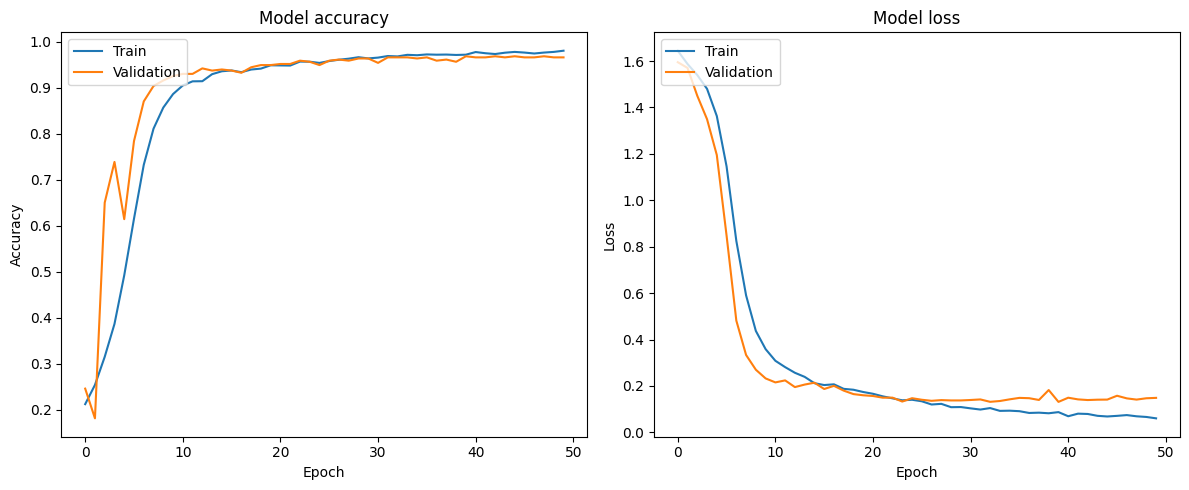

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step

Test Accuracy: 0.9665

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       184
           1       0.97      0.99      0.98        97
           2       0.95      0.86      0.90        42
           3       0.87      0.94      0.90        50
           4       1.00      0.96      0.98        45

    accuracy                           0.97       418
   macro avg       0.96      0.95      0.95       418
weighted avg       0.97      0.97      0.97       418



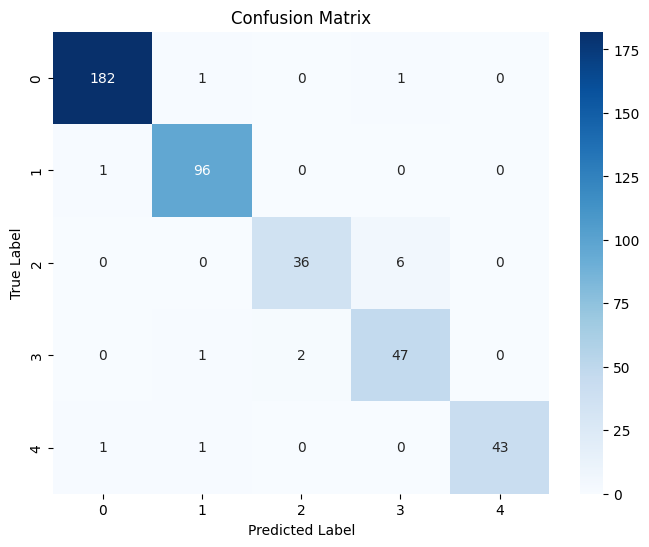

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_probs = model.predict(X_test_selected)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate Test Accuracy
test_accuracy = accuracy_score(y_test_int, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred, zero_division=0))

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test_int, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

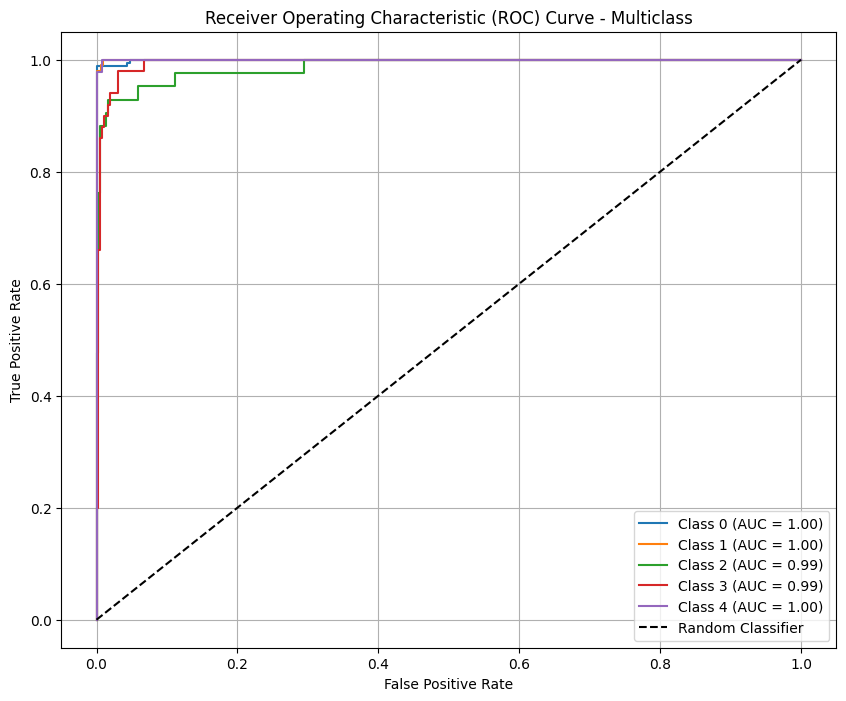

In [ ]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_test_int == i).astype(int), y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multiclass')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Summary of Model Performance

The Transformer model demonstrates strong performance in multiclass classification, as evidenced by the evaluation metrics from the confusion matrix and classification report.

**Overall Test Accuracy:**
*   The model achieved an overall test accuracy of **0.9665 (96.65%)**, indicating that it correctly classified the target class for nearly 97% of the samples in the unseen test dataset.

**Classification Report Analysis:**
*   **Class 0:** Shows excellent performance with precision, recall, and f1-score all at 0.99. This class is very well-identified, with minimal false positives or false negatives.
*   **Class 1:** Also performs very well, with high precision (0.97) and recall (0.99), resulting in an f1-score of 0.98.
*   **Class 2:** Has a precision of 0.95 and a recall of 0.86. While precision is high (when it predicts Class 2, it's usually correct), the recall is slightly lower, suggesting some instances of actual Class 2 might be missed or misclassified into other categories.
*   **Class 3:** Shows a precision of 0.87 and recall of 0.94. The recall is good, but precision is a bit lower, meaning some predictions for Class 3 might actually belong to other classes.
*   **Class 4:** Achieves perfect precision (1.00) and very high recall (0.96), leading to an f1-score of 0.98. This indicates excellent performance in identifying Class 4, with no false positives.

*   **Macro Average F1-score (0.95):** This is the unweighted average of the f1-scores for each class. It provides a good measure of performance across all classes, giving equal weight to each class regardless of its size.
*   **Weighted Average F1-score (0.97):** This average considers the support (number of true instances) for each class. It's closer to the overall accuracy because it accounts for the proportion of each class in the dataset.

**Confusion Matrix Insights:**
*   **True Positives:** The diagonal elements show the number of correctly classified instances for each class (e.g., 182 for Class 0, 96 for Class 1, 36 for Class 2, 47 for Class 3, 43 for Class 4).
*   **Misclassifications:** Off-diagonal elements highlight misclassifications:
    *   Class 2 has 6 instances incorrectly predicted as Class 3.
    *   Class 3 has 1 instance incorrectly predicted as Class 1, and 2 instances incorrectly predicted as Class 2.
    *   Class 4 has 1 instance incorrectly predicted as Class 0, and 1 instance incorrectly predicted as Class 1.
    *   Class 0 has 1 instance incorrectly predicted as Class 1 and 1 instance incorrectly predicted as Class 3.

In conclusion, the Transformer model demonstrates very strong predictive capabilities across most classes, with particular strengths in identifying Class 0, Class 1, and Class 4. While Classes 2 and 3 show slightly lower recall or precision, respectively, the overall performance remains high, suggesting the model is robust and generalizes well to unseen data after the applied preprocessing and feature selection steps.

### Strategies to Improve Performance for Class 2 and Class 3

The evaluation revealed that while the model generally performs well, there's room for improvement in correctly identifying Class 2 (lower recall) and Class 3 (lower precision). Here are some strategies to consider:

1.  **Refine SMOTE or Explore Other Resampling Techniques:**
    *   **Tuning SMOTE Parameters:** Experiment with different `k_neighbors` values in SMOTE to see if it generates more representative synthetic samples for Class 2 and Class 3.
    *   **Other Over-sampling Techniques:** Investigate techniques like ADASYN or Borderline-SMOTE, which focus on generating samples near decision boundaries.
    *   **Under-sampling:** Combine over-sampling with judicious under-sampling of majority classes to achieve a better balance.
    *   **Ensemble Resampling:** Use techniques like SMOTE-ENN or SMOTE-Tomek, which combine over-sampling with cleaning steps to remove noisy samples.

2.  **Feature Engineering and Selection:**
    *   **Domain-Specific Features:** Consult domain experts to identify if there are specific characteristics that strongly define Class 2 and Class 3, and try to engineer new features based on these insights.
    *   **Feature Interaction:** Create interaction terms between existing features that might be particularly relevant for these classes.
    *   **Re-evaluate Feature Selection:** While RFE was used, perhaps a different feature selection method or selecting a different number of features might yield a feature set that better discriminates between Class 2 and Class 3.

3.  **Model Hyperparameter Tuning:**
    *   **Transformer Model Parameters:** Systematically tune `embed_dim`, `num_heads`, `ff_dim`, `dropout_rate`, and `dense_neurons` using techniques like GridSearchCV or RandomizedSearchCV.
    *   **Learning Rate Schedule:** Implement a learning rate schedule (e.g., cosine decay, ReduceLROnPlateau) to allow the model to converge more effectively, potentially improving performance on harder-to-learn classes.

4.  **Adjust Class Weights:**
    *   When compiling the model, you can pass `class_weight` to the `model.fit()` method. This assigns higher weights to the minority classes (Class 2 and Class 3) during training, making the model pay more attention to correctly classifying them. For example: `class_weight = {0: 1, 1: 1, 2: 2, 3: 1.5, 4: 1}` (weights would need to be tuned).

5.  **Ensemble Methods:**
    *   **Stacking/Blending:** Combine the Transformer model with other types of classifiers (e.g., Gradient Boosting, Support Vector Machines) that might excel at distinguishing Class 2 and Class 3.
    *   **Bagging/Boosting:** Use ensemble methods like Bagging or AdaBoost with the Transformer as a base estimator, or use models like XGBoost, LightGBM, or CatBoost which inherently handle class imbalances and often perform well.

6.  **Error Analysis for Misclassified Samples:**
    *   **Qualitative Review:** Manually inspect samples that were misclassified for Class 2 and Class 3. Look for common patterns, unique features, or any data quality issues that might explain why the model struggled with them.
    *   **Feature Importance for Specific Classes:** Analyze which features are most influential for predicting Class 2 and Class 3, and whether these features are properly captured and utilized by the model.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_12 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_17            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_18            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_11 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_16            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

In [ ]:
batch_size = 32
epochs = 50 # Using the higher end of the suggested range (40-50)

y_train_smote_int = y_train_smote.astype(int)
y_test_int = y_test.astype(int)

history = model.fit(
    X_train_selected,
    y_train_smote_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_selected, y_test_int)
)


Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_10 │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_8  │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).

### Training History

Let's visualize the training and validation accuracy and loss over the epochs to evaluate the model's performance.

#### Build and Compile the Transformer Model

Now we'll put together the `TokenAndPositionEmbedding` layer and multiple `TransformerBlock` layers, followed by a final dense output layer for classification. We'll use the parameters specified by the user.

In [ ]:
# Model Parameters
embed_dim = 32  # Embedding dimension
num_heads = 4   # Number of attention heads
ff_dim = 64     # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of transformer blocks
dropout_rate = 0.3 # Dropout rate
dense_neurons = 64 # Neurons in the final dense layer

# Input features will be the number of selected features
input_shape = X_train_selected.shape[1] # 50 features

inputs = layers.Input(shape=(input_shape,))

# Embed tokens and positions
x = TokenAndPositionEmbedding(maxlen=input_shape, embed_dim=embed_dim)(inputs)

# Add multiple Transformer Blocks
for _ in range(num_transformer_blocks):
    x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(dense_neurons, activation="relu")(x)
x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
learning_rate = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_7  │ (None, 50, 32)         │         1,664 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 50, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 46,341 (181.02 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Transformer Model

Now, let's train the compiled model using the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) and validate it on the original test set (`X_test_selected`, `y_test`).